# Engine Health State Classification

In the previous regression task, the goal was to predict the **Remaining Useful Life (RUL)** of a turbofan engine from its sensor measurements.

In this notebook, we convert the problem into a **multi-class classification task**. Instead of predicting an exact RUL value, the model predicts the current **health severity** of the engine.

```text
Sensor Measurements → Health State
```

The engine condition is divided into three states:

| Health State    | Description                                                                |
| --------------- | -------------------------------------------------------------------------- |
| 🟢 **Healthy**  | The engine is operating far from failure.                                  |
| 🟡 **Warning**  | The engine shows significant degradation and requires increased attention. |
| 🔴 **Critical** | The engine is approaching failure and requires immediate attention.        |

These classes will be derived from the engine's RUL using predefined thresholds.

### Objective

The main objective is to develop an **Early Warning System** that can identify the severity of engine degradation from sensor measurements.

Because this is a predictive maintenance problem, the evaluation will focus not only on overall accuracy but also on the model's ability to correctly identify **Warning** and especially **Critical** conditions.



## Imports and Configuration

In [39]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## Load Prepared Data

In [2]:
file_names = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'train_engine_ids']

for name in file_names:
    globals()[name] = pd.read_csv(f'data/processed/{name}.csv')

In [3]:
X_train.shape, train_engine_ids.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((16561, 16),
 (16561, 1),
 (16561, 1),
 (4070, 16),
 (4070, 1),
 (100, 16),
 (100, 1))

In [4]:
y_train = y_train.squeeze()
y_val = y_val.squeeze()
y_test = y_test.squeeze()
train_engine_ids = train_engine_ids.squeeze()

## Define Health States

In [29]:
Healthy = 0
Warning = 1
Critical = 2

def map_to_class(rul):
    
    if rul > 100:   # healthy
        return 0
    elif rul > 30:  # warning
        return 1
    else:           # critical
        return 2

In [6]:
y_train = y_train.apply(map_to_class)
y_val = y_val.apply(map_to_class)
y_test = y_test.apply(map_to_class)

### Class Distribution Analysis


Text(0.5, 1.0, 'train distribiution')

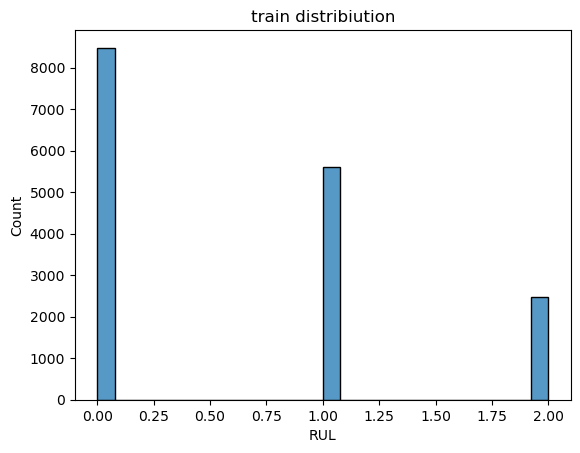

In [7]:
sns.histplot(y_train)
plt.title("train distribiution")

Text(0.5, 1.0, 'validation distribiution')

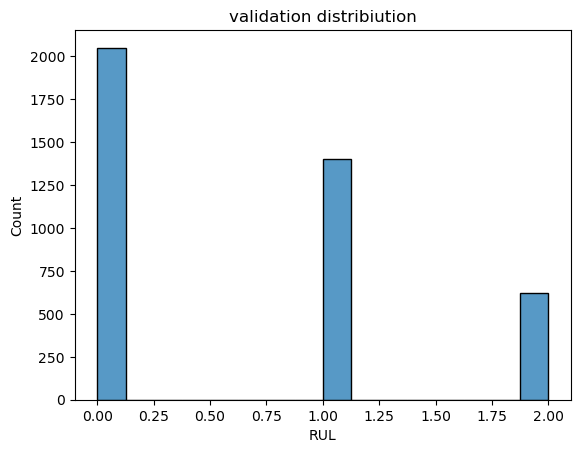

In [8]:
sns.histplot(y_val)
plt.title("validation distribiution")

The distribution plot reveals an asymmetrical pattern skewed toward healthier engines. To handle this class imbalance, we will apply techniques such as class weighting in the classification models.

Text(0.5, 1.0, 'test distribiution')

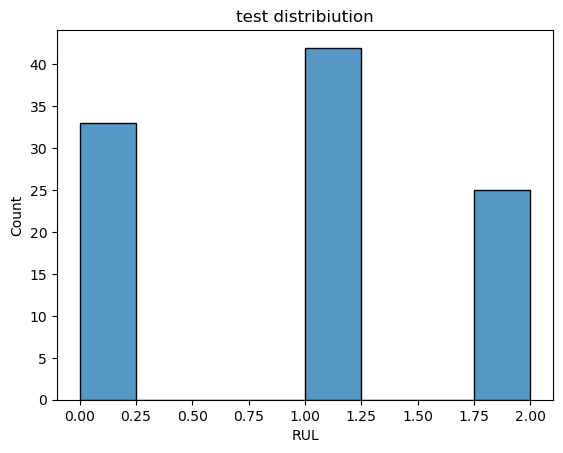

In [9]:
sns.histplot(y_test)
plt.title("test distribiution")


## Evaluation Metrics

We evaluate classification performance using **Accuracy, Balanced Accuracy, Macro F1, Critical Precision, and Critical Recall**.

* **Accuracy**: The proportion of all predictions that are correctly classified. Higher values indicate better overall performance.

* **Balanced Accuracy**: The average recall across all classes. It is particularly useful when the dataset is imbalanced because each class contributes equally to the final score.

* **Macro F1**: The average F1-score across all classes, giving equal importance to Healthy, Warning, and Critical states. Higher values indicate more balanced performance across classes.

* **Critical Precision**: The proportion of engines predicted as **Critical** that are actually Critical. Higher values indicate fewer false alarms for the Critical state.

* **Critical Recall**: The proportion of truly **Critical** engines that are correctly identified by the model. This is especially important for the Early Warning System because missing a Critical engine can be more serious than generating a false alarm.

* **Confusion Matrix**: A matrix that shows how the model's predictions are distributed across the actual classes. It helps identify which health states are being confused with each other, particularly whether **Critical** engines are incorrectly classified as Healthy or Warning.


For this predictive maintenance task, **Macro F1, Balanced Accuracy, and Critical Recall** are considered the primary evaluation metrics, while Accuracy and Critical Precision provide additional context.


In [ ]:

def evaluate(y_true, y_pred, model_name):
    metrics={
        
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Critical Precision": precision_score(
            y_true, 
            y_pred, 
            labels=[Critical], 
            average="macro", 
            zero_division=0
        ),
        "Critical Recall": recall_score(
            y_true, 
            y_pred, 
            labels=[Critical], 
            average="macro", 
            zero_division=0
        )
    }
    return pd.DataFrame([metrics]).round(2)

In [ ]:

def plot_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Warning", "Critical"]
    )

    disp.plot(cmap="Blues", values_format="d")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

## Baseline Model

### Logistic Regression

In [ ]:

model_lr = LogisticRegression(
    multi_class='multinomial',   
    solver='lbfgs',              
    class_weight='balanced',
    max_iter=1000,             
    random_state=42,
    C=1.0                     
)


model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_val)

c:\Users\hosse\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
evaluate(y_val, y_pred_lr, "logistic regression")

,model,Accuracy,Balanced Accuracy,Macro F1,Critical Precision,Critical Recall
0,logistic regression,0.79,0.82,0.8,0.81,0.94


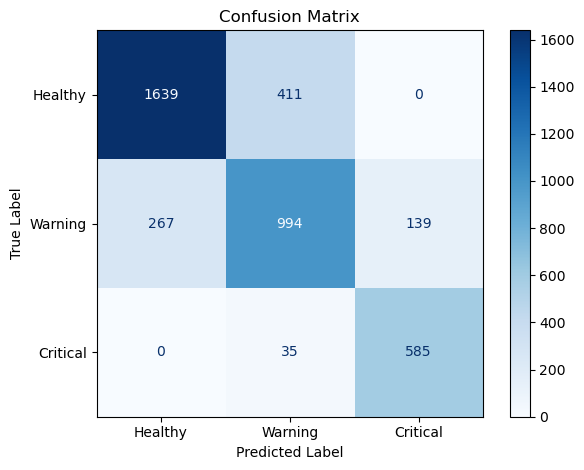

In [38]:
plot_cm(y_val, y_pred_lr)